# Module 5 Lab 2: Housing type bar chart (Problem 5.3)
**Name:** (your name)  
**GitHub repo:** https://github.com/roee0910/cs82a-portfolio (folder `module5/`)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# custdata.tsv is tab-separated
cust = pd.read_csv("custdata.tsv", sep="	")
print(cust.shape)
print(cust["housing.type"].value_counts(dropna=False))

(1000, 11)
housing.type
Homeowner with mortgage/loan    412
Rented                          364
Homeowner free and clear        157
NaN                              56
Occupied with no rent            11
Name: count, dtype: int64


## Step 1: Look at the missing entries first

In [2]:
# pandas turns the text "NA" into a missing value (NaN), so isna() finds them
n_before = len(cust)
n_na = cust["housing.type"].isna().sum()
print("Rows before cleaning:", n_before)
print("Rows with missing housing type:", n_na)

Rows before cleaning: 1000
Rows with missing housing type: 56


## Step 2: Remove the NA rows and count what was dropped

In [3]:
clean = cust.dropna(subset=["housing.type"])
n_after = len(clean)
excluded = n_before - n_after
print("Rows after cleaning:", n_after)
print("Rows excluded:", excluded)

# self-check: the numbers must add up and no NA category may remain
assert excluded == n_na
assert clean["housing.type"].isna().sum() == 0
assert (clean["housing.type"] != "NA").all()

Rows after cleaning: 944
Rows excluded: 56


**Rows excluded:** 56 of the 1,000 rows (5.6%) were removed because their housing type was NA, leaving 944 customers in the chart.

## Step 3: Counts per housing type (sorted)

In [4]:
counts = clean["housing.type"].value_counts()   # already sorted largest to smallest
print(counts)
print("Total:", counts.sum())

housing.type
Homeowner with mortgage/loan    412
Rented                          364
Homeowner free and clear        157
Occupied with no rent            11
Name: count, dtype: int64
Total: 944


## Step 4: Sorted, labeled bar chart

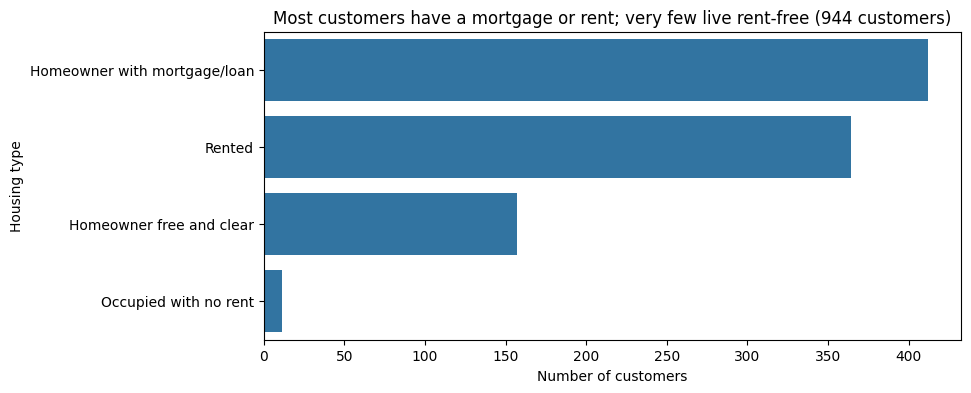

In [5]:
plt.figure(figsize=(9, 4))
sns.countplot(data=clean, y="housing.type", order=counts.index)
plt.title("Most customers have a mortgage or rent; very few live rent-free (944 customers)")
plt.xlabel("Number of customers")
plt.ylabel("Housing type")
plt.show()

## Honest-chart notes

1. The NA rows were removed first, so the chart has only the four real housing types and the bars add up to 944 customers.
2. The bars are sorted from largest to smallest, the count axis starts at zero, and both axes have labels, so the sizes can be compared fairly.